In [2]:
%pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers, models

In [10]:
# Load Data

apple = np.load("full_numpy_bitmap_apple.npy")
bird = np.load("full_numpy_bitmap_bird.npy")
donut = np.load("full_numpy_bitmap_donut.npy")
mushroom = np.load("full_numpy_bitmap_mushroom.npy")

SAMPLES_PER_DATA = 2000

# X data / inputs
apple = apple[:SAMPLES_PER_DATA]
bird = bird[:SAMPLES_PER_DATA]
donut = donut[:SAMPLES_PER_DATA]
mushroom = mushroom[:SAMPLES_PER_DATA]

# Y data / labels
y_apple = np.zeros(len(apple))
y_bird = np.ones(len(bird))
y_donut = np.full(len(donut), 2)
y_mushroom = np.full(len(mushroom), 3)

# Combine
X = np.concatenate([apple, bird, donut, mushroom])
y = np.concatenate([y_apple, y_bird, y_donut, y_mushroom])

# Normalize and Reshape
X = X / 255.0
X = X.reshape(-1, 28, 28, 1)

print(X.shape)
print(y.shape)

(8000, 28, 28, 1)
(8000,)


In [11]:
# Train, Validation, and Test set split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(X_train.shape)
print(y_train.shape)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(5780, 28, 28, 1)
(5780,)
(1020, 28, 28, 1)
(1020,)
(1200, 28, 28, 1)
(1200,)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

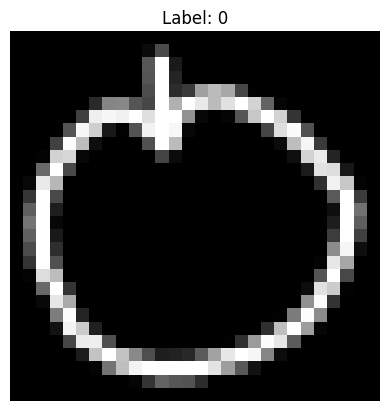

In [16]:
plt.imshow(X_train[0].reshape(28, 28), cmap="gray")
plt.title(f"Label: {int(y_train[0])}")
plt.axis("off")

In [27]:
# Neural Network Architecture
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(4, activation="softmax")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 894,980 (3.41 MB)

 Trainable params: 894,980 (3.41 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train the train set and dev set
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train, 
    epochs=25,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8702 - loss: 0.3767 - val_accuracy: 0.9637 - val_loss: 0.1367
Epoch 2/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9481 - loss: 0.1701 - val_accuracy: 0.9706 - val_loss: 0.1168
Epoch 3/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9573 - loss: 0.1372 - val_accuracy: 0.9725 - val_loss: 0.1106
Epoch 4/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9600 - loss: 0.1196 - val_accuracy: 0.9696 - val_loss: 0.1135
Epoch 5/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9671 - loss: 0.0951 - val_accuracy: 0.9775 - val_loss: 0.1028
Epoch 6/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9711 - loss: 0.0812 - val_accuracy: 0.9784 - val_loss: 0.1138
Epoch 7/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9772 - loss: 0.0677 - val_accuracy: 0.9706 - val_loss: 0.1106
Epoch 8/25
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9813 - loss: 0.0547 - val_accuracy: 0.9716 - v

In [29]:
# Test the accuracy (Test set)
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9642 - loss: 0.2533 
Test accuracy: 0.9641666412353516


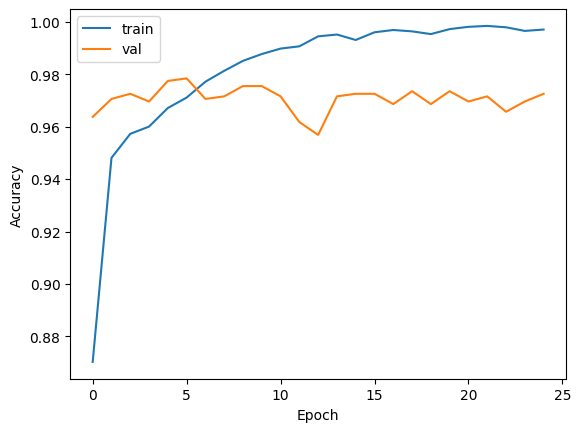

In [30]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [39]:
import cv2

class_names = ['apple', 'bird', 'donut', 'mushroom']

canvas = np.ones((280,280), dtype=np.uint8) * 255
drawing = False

def draw(event, x, y, flags, param):
    global drawing
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        cv2.circle(canvas, (x,y), 8, 0, -1)

word = input("Please choose which object you want to draw? [Apple, Bird, Donut, Mushroom]: ")

cv2.namedWindow(f"Draw {word}")
cv2.setMouseCallback(f"Draw {word}", draw)

while True:
    cv2.imshow(f"Draw {word}", canvas)
    key = cv2.waitKey(1)
    if key == 27:
        break

cv2.destroyAllWindows()

# Resize the image from canvas
img = cv2.resize(canvas, (28,28))
img = img / 255.0
img = 1-img
img = img.reshape(1, 28, 28, 1)

# Prediction
pred = model.predict(img)
pred_index = np.argmax(pred)

print("Prediction:", class_names[pred_index])
print("Confidence:", pred[0][pred_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction: donut
Confidence: 1.0
